### Student Information
Name: Robin Schroth

Student ID: 114751801

GitHub ID: robins114

---

### Instructions

### First Phase Submission

1. First: do the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) that considered as **phase 1 (from exercise 1 to exercise 15)**. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: follow the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** up **until phase 1**. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    -  Use [the new dataset](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/newdataset/Reddit-stock-sentiment.csv). The dataset contains a 16 columns including 'text' and 'label', with the sentiment labels being: 1.0 is positive, 0.0 is neutral and -1.0 is negative. You can simplify the dataset and use only the columns that you think are necessary.
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.
    - Use this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output.


3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 10% of your grade.__
    - Generate meaningful **new data visualizations**. Refer to online resources and the Data Mining textbook for inspiration and ideas.
    


4. Fourth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__

You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (September 28th 11:59 pm, Sunday)__.

### Second Phase Submission

**You can keep the answer for phase 1 for easier running and update the phase 2 on the same page.**

1. First: Continue doing the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) for **phase 2, starting from Finding frequent patterns**. Use the same master(.ipynb) file. Answer from phase 1 will not be considered at this stage. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: Continue from first phase and do the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** for phase 2, starting from Finding frequent pattern. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    - Continue using this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output. Use the same new dataset as in phase 1.
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.

3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 20% of your grade.__
    - Use this file to answer.
    - Generate **TF-IDF features** from the tokens of each text. This will generating a document matrix, however, the weights will be computed differently (using the TF-IDF value of each word per document as opposed to the word frequency).  Refer to this Scikit-learn [guide](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) .
    - Implement a simple **Naive Bayes classifier** that automatically classifies the records into their categories. Use both the TF-IDF features and word frequency features to build two seperate classifiers. Note that for the TF-IDF features you might need to use other type of NB classifier different than the one in the Master Notebook. Comment on the differences and when using augmentation with feature pattern.  Refer to this [article](https://hub.packtpub.com/implementing-3-naive-bayes-classifiers-in-scikit-learn/).


4. Fourth: In the lab, we applied each step really quickly just to illustrate how to work with your dataset. There are somethings that are not ideal or the most efficient/meaningful. Each dataset can be handled differently as well. What are those inefficent parts you noticed? How can you improve the Data preprocessing for these specific datasets? __This part is worth 10% of your grade.__


5. Fifth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__


You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (October 19th 11:59 pm, Sunday)__.

# Phase 1

In [1]:
!pip install numpy pandas matplotlib plotly nltk scikit-learn seaborn pami umap-learn
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [2]:
# test code for environment setup
import pandas as pd
import numpy as np
import nltk
nltk.download('punkt') # download the NLTK datasets
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
import plotly as py
import math
# If you get "ModuleNotFoundError: No module named 'PAMI'"
# run the following in a new Jupyter cell:
#!pip3 install PAMI
import PAMI
import umap

categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']
twenty_train = fetch_20newsgroups(subset='train', categories=categories, shuffle=True, random_state=42)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [3]:
# Repo klonen
!git clone https://github.com/robins114/DM2025-Lab1-Exercise.git

# Ins Repo wechseln
%cd DM2025-Lab1-Exercise

# Jetzt klappt der Import
import helpers.data_mining_helpers as dmh

Cloning into 'DM2025-Lab1-Exercise'...
remote: Enumerating objects: 245, done.
remote: Counting objects: 100% (96/96), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 245 (delta 74), reused 50 (delta 50), pack-reused 149 (from 1)
Receiving objects: 100% (245/245), 28.05 MiB | 22.85 MiB/s, done.
Resolving deltas: 100% (118/118), done.
/content/DM2025-Lab1-Exercise


In [4]:
### Begin Assignment Here### Set up the environment
import pandas as pd
import numpy as np
import nltk
from sklearn.feature_extraction.text import CountVectorizer
import plotly as py
import math
import PAMI
import umap

# (Autoreload ist in Python 3.12 kaputt, deshalb besser auskommentieren)
# %reload_ext autoreload
# %autoreload 2

import sys
print(sys.executable)  # path to Python
print(sys.version)     # python version

# === CSV-Datei von deinem iPad hochladen ===
from google.colab import files

uploaded = files.upload()   # öffnet Dateiauswahl auf deinem iPad
csv_filename = list(uploaded.keys())[0]  # nimmt den Dateinamen der hochgeladenen Datei

# CSV einlesen
df = pd.read_csv(csv_filename)

print("Rownames:", df.columns.tolist())
print(df.head())

# Create DataFrame with text and labels
X = pd.DataFrame({
    'text': df['text'].astype(str),   # ensure text is string
    'label': df['label'].astype(int)  # ensure label is integer
})

# Map numeric labels (-1, 0, 1) to readable categories
label_map = {-1: 'negative', 0: 'neutral', 1: 'positive'}
X['category_name'] = X['label'].map(label_map)

# Control check
print(X[['label', 'category_name']].head(10))

/usr/bin/python3
3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]


Saving Reddit-stock-sentiment.csv to Reddit-stock-sentiment.csv
Rownames: ['type', 'datetime', 'post_id', 'subreddit', 'title', 'author', 'url', 'upvotes', 'downvotes', 'upvote_ratio', 'text', 'subjectivity', 'polarity', 'sentiment', 'entities', 'label']
      type             datetime  post_id         subreddit  \
0  comment  2025-04-11 17:29:56  mmli62w    wallstreetbets   
1  comment   2025-04-12 1:12:19  mmnu7v9    wallstreetbets   
2  comment  2025-04-10 15:09:41  mmeevio       StockMarket   
3     post  2023-08-30 17:12:55  165kllm  stockstobuytoday   
4  comment  2025-04-11 14:48:05  mmkl6bw       StockMarket   

                                               title                author  \
0    Retardation is on the menu boys! WSB is so back          StickyTip420   
1  Retail giant TARGET has now declined for 10 co...  Comfortable-Dog-8437   
2  How do you feel about a sitting president maki...          Btankersly66   
3                              Who knows more? $VMAR        

In [5]:
# Excercise 1
# Define texts from the DataFrame
texts = X['text'].tolist()

# Exercise 1
for i in range(3):
    print(f"Example {i+1}")
    print("\n".join(texts[i].split("\n")))

Example 1
Calls on retards
Example 2
Stunt as in like why did they even make a big deal about starting it in the first place? No company should ever talk about politics ever.
Example 3
Seeing lots of red in the ticker.


In [6]:
import pandas as pd
# Texts should be a flat list of Strings
texts = [str(t) for t in texts]

# Create DataFrame
X = pd.DataFrame({
    'text': df['text'].astype(str),
    'label': df['label'].astype(int)
})

# Mapping von label (-1,0,1) to negative, neutral and positive
label_map = {-1: 'negative', 0: 'neutral', 1: 'positive'}
X['category_name'] = X['label'].map(label_map)

# Control
print(X[['label', 'category_name']].head(10))

   label category_name
0     -1      negative
1      0       neutral
2      0       neutral
3      1      positive
4     -1      negative
5      0       neutral
6     -1      negative
7      0       neutral
8      1      positive
9      1      positive


In [7]:
# Exercise 2

# Length of the dataset
print("Number of rows in the dataset:", len(X))

# First row from the dataset
print("First row:")
print(X.iloc[0])

# Last row from the dataset
print("Last row:")
print(X.iloc[-1])


Number of rows in the dataset: 847
First row:
text             Calls on retards
label                          -1
category_name            negative
Name: 0, dtype: object
Last row:
text             ![img](emote|t5_2th52|31224)
label                                       0
category_name                         neutral
Name: 846, dtype: object


In [8]:
# Exercise 3

# Select every 10th record in the "positive" category and take the first 5
X_positive_sampled = X[X['category_name'] == 'positive'].iloc[::10].head(5)

# Print the sampled records
print("Sample of every 10th 'positive' record (first 5):")
print(X_positive_sampled)

Sample of every 10th 'positive' record (first 5):
                                                  text  label category_name
3    Vision Marine Technologies Inc. is rewriting t...      1      positive
78   I think it’s gonna work itself out. I bought t...      1      positive
168  The obvious can also be refreshing from CNBC: ...      1      positive
219  Same. Back to break even after that last rip b...      1      positive
319  Etrade has a feed of news articles about how r...      1      positive


In [13]:
# Repo klonen
!git clone https://github.com/robins114/DM2025-Lab1-Exercise.git

# Ins Repo wechseln
%cd DM2025-Lab1-Exercise

# Jetzt klappt der Import
import helpers.data_mining_helpers as dmh

Cloning into 'DM2025-Lab1-Exercise'...
remote: Enumerating objects: 245, done.
remote: Counting objects: 100% (96/96), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 245 (delta 74), reused 50 (delta 50), pack-reused 149 (from 1)
Receiving objects: 100% (245/245), 28.05 MiB | 22.53 MiB/s, done.
Resolving deltas: 100% (118/118), done.
/content/DM2025-Lab1-Exercise/DM2025-Lab1-Exercise/DM2025-Lab1-Exercise


In [14]:
# Exercise 4
#import helpers.data_mining_helpers_Homework as dmh
# Count missing values per row (axis=1)
# Uses the helper function check_missing_values from your dmh module
missing_per_row = X.isnull().apply(lambda row: dmh.check_missing_values(row), axis=1)

# For control: show missing values in the first 5 rows
print("Missing values per row (first 5 rows):")
print(missing_per_row.head(5))

Missing values per row (first 5 rows):
0    (The amoung of missing records is: , 0)
1    (The amoung of missing records is: , 0)
2    (The amoung of missing records is: , 0)
3    (The amoung of missing records is: , 0)
4    (The amoung of missing records is: , 0)
dtype: object


In [15]:
#Check if there are duplicates
sum(X.duplicated('text')) # there are 23 text duplicates in the data

23

In [16]:
# Dealing with duplicate data
X['datetime'] = df['datetime']
sum(X.duplicated('datetime'))

# only 5 datetimes are the same, so maybe 23 comments have been taken at a different time, but the user used the same text
# can be not a duplicate, as the time might be different

5

category_name
neutral     9
negative    8
positive    3
Name: count, dtype: int64


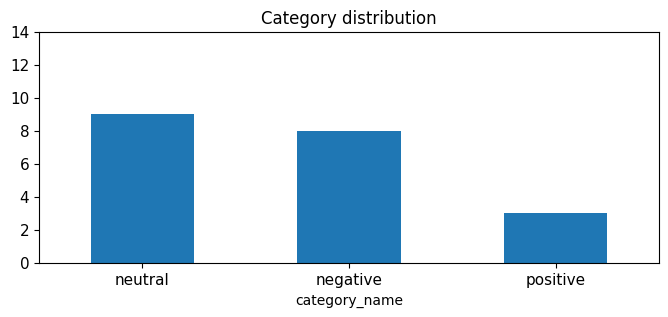

In [21]:
# Exercise 5 and 6, same answer

# Exercise 7

# Data Preprocessing
import matplotlib.pyplot as plt
%matplotlib inline

# Optional: random selection of 20 samples
X_sample = X.sample(n=20, random_state=42)

# Count entries in the category
print(X_sample.category_name.value_counts())

# Barchart
X_sample.category_name.value_counts().plot(
    kind='bar',
    title='Category distribution',
    ylim=[0, X_sample.category_name.value_counts().max()+5],
    rot=0,
    fontsize=11,
    figsize=(8,3)
)

plt.show()

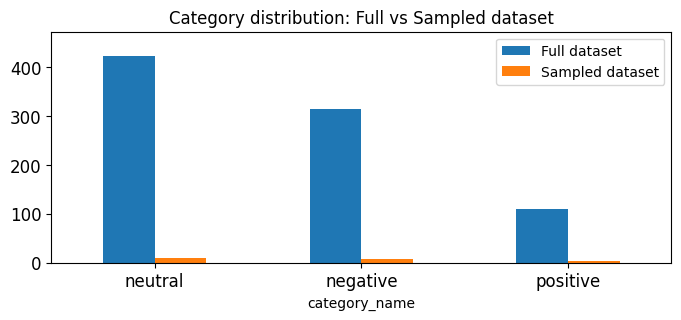

In [22]:
# Excercise 8

# Counts for both datasets
counts_df = pd.DataFrame({
    'Full dataset': X['category_name'].value_counts(),
    'Sampled dataset': X_sample['category_name'].value_counts()
})

# Define ylim as the highest value plus 10
y_max = max(counts_df.max()) + 50

# Plot
counts_df.plot(
    kind='bar',
    title='Category distribution: Full vs Sampled dataset',
    ylim=[0, y_max],
    rot=0,
    fontsize=12,
    figsize=(8,3)
)

plt.show()

In [23]:
# Feature Creation
import nltk
nltk.download("punkt")
#import helpers.data_mining_helpers_Homework as dmh

# Feature Creation: tokenize text into unigrams
X['unigrams'] = X['text'].apply(lambda x: dmh.tokenize_text(x))

# First 5 lines
print(X[['text', 'unigrams']].head())
# To test it further
list(X[0:2]['unigrams'])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


# Phase 2

In [ ]:
### Begin Assignment Here